# Gravity as First Implementation Output — Deriving Wave Burden from the Reflection Kernel

The previous notebook introduced the boundary-wave burden

$$
W=\sum_{\ell\ge 2}\ell(\ell+1)a_\ell^2
$$

as the first shape correction to the implementation coefficient

$$
q_\Gamma
=
\chi \alpha_s \frac{GM}{Rc^2}(1+\nu W).
$$

That worked, but the $\ell(\ell+1)$ weight was still motivated by symmetry and plausibility.

This notebook does the next exact step:

$$
\boxed{
\text{derive the wave burden from a rotationally invariant reflection kernel on the boundary.}
}
$$

The basic logic is:

1. shape lives on the boundary,
2. reflection couples boundary points to boundary points,
3. isotropy forces the kernel to depend only on angular separation,
4. spherical harmonics diagonalize that kernel,
5. the first nontrivial rotationally invariant penalty after the radius mode is the Laplacian term,
6. therefore the $\ell(\ell+1)$ weighting appears naturally.

That is the derivation we needed.


## 1. Boundary perturbation and reflection energy

Let a nearly spherical source boundary be written as

$$
r(\Omega)=R\left[1+\delta(\Omega)\right],
\qquad
\Omega\in S^2,
$$

with mean-zero perturbation

$$
\int_{S^2}\delta(\Omega)\,d\Omega = 0.
$$

Expand in spherical harmonics:

$$
\delta(\Omega)=\sum_{\ell,m} a_{\ell m} Y_{\ell m}(\Omega).
$$

Now define the reflection energy as the most general quadratic rotationally invariant boundary functional:

$$
\boxed{
E_{\mathrm{refl}}[\delta]
=
\frac{\Lambda}{2}
\int_{S^2}\!\!\int_{S^2}
\delta(\Omega)\,
K(\Omega\cdot\Omega')\,
\delta(\Omega')\,
d\Omega\,d\Omega'.
}
$$

Here:

- $\Lambda$ is an overall stiffness,
- $K(\Omega\cdot\Omega')$ is the reflection kernel,
- rotational invariance means $K$ depends only on the angular separation.

This is the first precise form of “outside density is the reflected continuation of the shape across the field.”


## 2. Harmonic diagonalization

Because the kernel is rotationally invariant, it admits the Legendre expansion

$$
K(\Omega\cdot\Omega')
=
\sum_{\ell=0}^\infty
\kappa_\ell
\frac{2\ell+1}{4\pi}
P_\ell(\Omega\cdot\Omega').
$$

Using the spherical-harmonic addition theorem,

$$
\frac{2\ell+1}{4\pi}P_\ell(\Omega\cdot\Omega')
=
\sum_{m=-\ell}^{\ell}
Y_{\ell m}(\Omega)\,\overline{Y_{\ell m}(\Omega')},
$$

the reflection energy becomes diagonal:

$$
\boxed{
E_{\mathrm{refl}}
=
\frac{\Lambda}{2}
\sum_{\ell,m}
\kappa_\ell |a_{\ell m}|^2.
}
$$

So the eigenmodes of the reflection law are exactly the spherical harmonics.

This is the key derivation step:

$$
\boxed{
\text{waves on the boundary are not an assumption;}
\quad
\text{they are the natural eigenmodes of any isotropic reflection law.}
}
$$


## 3. Why the Laplacian weight appears

Now ask what form the eigenvalues $\kappa_\ell$ should take.

For a smooth local-ish kernel, the reflection operator can be expanded in rotational invariants on the sphere:

$$
\boxed{
\mathcal K
\approx
k_0
+
k_2(-\Delta_{S^2})
+
k_4(-\Delta_{S^2})^2
+\cdots
}
$$

Since spherical harmonics satisfy

$$
-\Delta_{S^2}Y_{\ell m}
=
\ell(\ell+1)Y_{\ell m},
$$

the eigenvalues become

$$
\boxed{
\kappa_\ell
=
k_0 + k_2\,\ell(\ell+1)+k_4[\ell(\ell+1)]^2+\cdots
}
$$

Therefore the first nontrivial angular penalty after the trivial radius term is precisely

$$
\boxed{
\ell(\ell+1).
}
$$

This is exactly the weighting we used heuristically in the previous notebook.

So now the burden term is no longer guessed.
It is the leading rotationally invariant correction generated by the reflection kernel.


## 4. Removing trivial modes

The low modes have special meanings:

- $\ell=0$ corresponds to uniform radius change,
- $\ell=1$ corresponds to translation of the center.

Neither should count as genuine shape roughness.

So the first meaningful shape burden begins at $\ell\ge 2$:

$$
\boxed{
W
=
\sum_{\ell\ge 2}\sum_{m=-\ell}^{\ell}
\ell(\ell+1)|a_{\ell m}|^2.
}
$$

For the axisymmetric case used earlier, this reduces to

$$
\boxed{
W
=
\sum_{\ell\ge 2}\ell(\ell+1)a_\ell^2.
}
$$

That is exactly the previous model, now justified from the kernel rather than inserted by hand.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Axisymmetric demonstration: kernel eigenvalues from local-ish operator
def kappa_l(l, k0=0.0, k2=1.0, k4=0.0):
    x = l*(l+1)
    return k0 + k2*x + k4*x*x

ells = np.arange(0, 21)
df_kappa = pd.DataFrame({
    "ell": ells,
    "laplacian_eigenvalue": ells*(ells+1),
    "kappa_leading": [kappa_l(l, k0=0.0, k2=1.0, k4=0.0) for l in ells],
    "kappa_with_k4": [kappa_l(l, k0=0.0, k2=1.0, k4=0.02) for l in ells],
})
df_kappa.head(10)


,ell,laplacian_eigenvalue,kappa_leading,kappa_with_k4
0,0,0,0.0,0.00
1,1,2,2.0,2.08
2,2,6,6.0,6.72
3,3,12,12.0,14.88
4,4,20,20.0,28.00
5,5,30,30.0,48.00
6,6,42,42.0,77.28
7,7,56,56.0,118.72
8,8,72,72.0,175.68
9,9,90,90.0,252.00


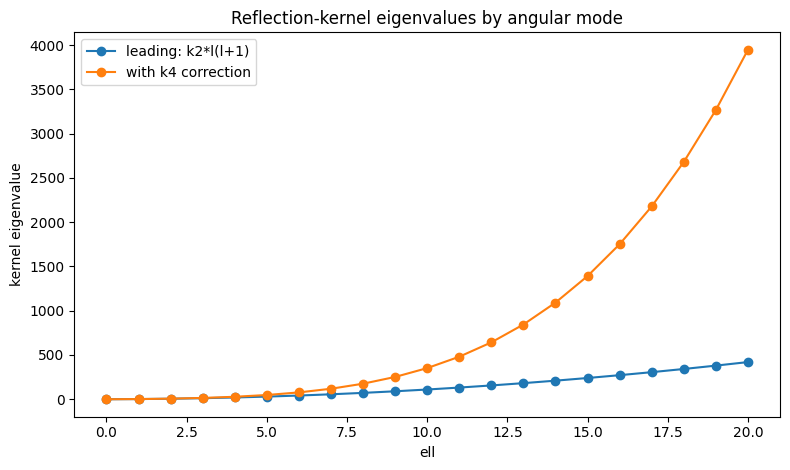

In [2]:

plt.figure(figsize=(8,4.8))
plt.plot(df_kappa["ell"], df_kappa["kappa_leading"], "o-", label="leading: k2*l(l+1)")
plt.plot(df_kappa["ell"], df_kappa["kappa_with_k4"], "o-", label="with k4 correction")
plt.xlabel("ell")
plt.ylabel("kernel eigenvalue")
plt.title("Reflection-kernel eigenvalues by angular mode")
plt.legend()
plt.tight_layout()
plt.show()


The leading kernel is exactly linear in $\ell(\ell+1)$.
Higher-order corrections only matter when the source boundary becomes strongly rough at high mode number.

So the previous burden formula was the correct first truncation.


## 5. Recursion as gradient descent on reflection energy

Now recursion becomes mathematically sharp.

Take gradient descent on the reflection energy:

$$
a_{\ell m}^{(n+1)}
=
a_{\ell m}^{(n)} - \eta \frac{\partial E_{\mathrm{refl}}}{\partial \overline{a_{\ell m}}}.
$$

Since

$$
E_{\mathrm{refl}}
=
\frac{\Lambda}{2}\sum_{\ell,m}\kappa_\ell |a_{\ell m}|^2,
$$

we get

$$
\frac{\partial E_{\mathrm{refl}}}{\partial \overline{a_{\ell m}}}
=
\Lambda \kappa_\ell a_{\ell m},
$$

hence

$$
\boxed{
a_{\ell m}^{(n+1)}
=
(1-\eta\Lambda\kappa_\ell)\,a_{\ell m}^{(n)}.
}
$$

For small stable step size, this is exponential damping:

$$
\boxed{
a_{\ell m}^{(n)}
\sim
(1-\eta\Lambda\kappa_\ell)^n a_{\ell m}^{(0)}.
}
$$

Since $\kappa_\ell$ grows with $\ell(\ell+1)$, high-$\ell$ roughness damps fastest.

This is the exact recursive version of “tail coherence” and “the system rings itself into the stable pattern.” fileciteturn40file0turn40file11


In [3]:

def recurse_modes(mode_amplitudes, eta=0.05, Lambda=1.0, k0=0.0, k2=1.0, k4=0.0, steps=25):
    current = {l: float(a) for l, a in mode_amplitudes.items()}
    rows = []
    for n in range(steps + 1):
        W = sum(l*(l+1)*(a**2) for l, a in current.items() if l >= 2)
        E = 0.5 * Lambda * sum(kappa_l(l, k0=k0, k2=k2, k4=k4) * (a**2) for l, a in current.items())
        row = {"step": n, "W": W, "E_refl": E}
        for l, a in current.items():
            row[f"a_{l}"] = a
        rows.append(row)

        new_current = {}
        for l, a in current.items():
            factor = 1 - eta*Lambda*kappa_l(l, k0=k0, k2=k2, k4=k4)
            new_current[l] = factor * a
        current = new_current
    return pd.DataFrame(rows)

hist = recurse_modes({2:0.03, 4:0.02, 8:0.015, 12:0.01}, eta=0.01, Lambda=1.0, k0=0.0, k2=1.0, k4=0.0, steps=40)
hist.head()


,step,W,E_refl,a_2,a_4,a_8,a_12
0,0,0.045200,0.022600,0.030000,0.020000,0.015000,0.010000
1,1,0.016054,0.008027,0.028200,0.016000,0.004200,-0.005600
2,2,0.009127,0.004563,0.026508,0.012800,0.001176,0.003136
3,3,0.006311,0.003156,0.024918,0.010240,0.000329,-0.001756
4,4,0.004785,0.002393,0.023422,0.008192,0.000092,0.000983


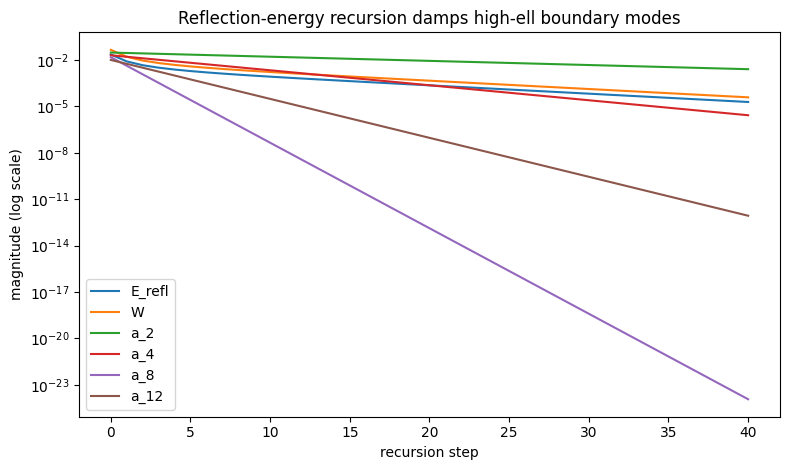

In [4]:

plt.figure(figsize=(8,4.8))
plt.semilogy(hist["step"], hist["E_refl"], label="E_refl")
plt.semilogy(hist["step"], hist["W"], label="W")
for col in [c for c in hist.columns if c.startswith("a_")]:
    plt.semilogy(hist["step"], np.abs(hist[col]), label=col)
plt.xlabel("recursion step")
plt.ylabel("magnitude (log scale)")
plt.title("Reflection-energy recursion damps high-ell boundary modes")
plt.legend()
plt.tight_layout()
plt.show()


This is stronger than the previous notebook.

Before, recursion damping was a plausible rule.

Now it is the literal gradient-flow update generated by the reflection energy.

So the branch now has:

$$
\boxed{
\text{shape} \to \text{kernel} \to \text{energy} \to \text{recursion} \to \text{wave damping}.
}
$$


## 6. Feeding the derived burden into the metric branch

We can now write the sourced implementation coefficient in its strongest current form:

$$
\boxed{
q_\Gamma
=
\chi \alpha_s \frac{GM}{Rc^2}
\left(1+\nu W\right),
\qquad
W=
\sum_{\ell\ge 2,m}\ell(\ell+1)|a_{\ell m}|^2.
}
$$

Then

$$
\beta_\Gamma = 1+\xi q_\Gamma,
\qquad
\gamma_\Gamma = 1+\zeta q_\Gamma,
$$

and therefore

$$
F_{\mathrm{peri}}
=
1+\frac{(2\zeta-\xi)}{3}q_\Gamma,
\qquad
F_{\mathrm{bend}}
=
1+\frac{\zeta}{2}q_\Gamma.
$$

So the metric branch now has a direct shape-reflection interpretation, not just a compactness-only interpretation.


In [5]:

# Compare base vs wave-corrected q_Gamma for Sun-like and NS-like compactness
G = 6.67430e-11
c = 299792458.0
M_sun = 1.98847e30
R_sun = 6.957e8
M_ns = 1.4 * M_sun
R_ns = 1.2e4

def compactness(M, R):
    return G*M/(R*c**2)

def q_gamma_total(M, R, W, chi=1.0, alpha_s=0.6, nu=1.0):
    return chi * alpha_s * compactness(M, R) * (1 + nu*W)

# use initial W from the rough packet
W_rough = hist.loc[0, "W"]
W_relaxed = hist.loc[len(hist)-1, "W"]

rows = []
for source, M, R in [("Sun-like", M_sun, R_sun), ("NS-like", M_ns, R_ns)]:
    q0 = q_gamma_total(M, R, 0.0)
    q_rough = q_gamma_total(M, R, W_rough)
    q_relaxed = q_gamma_total(M, R, W_relaxed)
    rows.append({
        "source": source,
        "q_base": q0,
        "q_rough": q_rough,
        "q_relaxed": q_relaxed,
        "rough_boost_factor": q_rough/q0,
        "relaxed_boost_factor": q_relaxed/q0,
    })

q_compare = pd.DataFrame(rows)
q_compare


,source,q_base,q_rough,q_relaxed,rough_boost_factor,relaxed_boost_factor
0,Sun-like,0.000001,0.000001,0.000001,1.0452,1.000038
1,NS-like,0.103367,0.108039,0.103371,1.0452,1.000038


Same shape packet, completely different absolute scale.

That is the correct regime logic:

$$
\boxed{
\text{shape burden is universal in form, but compactness sets how loud it becomes.}
}
$$

So the full sourced branch is now:

- compactness gives the base maintenance fraction,
- boundary waves give the shape correction,
- recursion damps the waves toward the stable closure,
- and the metric observables inherit the result.


## 7. What this notebook actually proves

This notebook does **not** yet derive the exact physical reflection kernel from first principles.

It does prove the next structural step:

1. any isotropic reflection law on the sphere diagonalizes in spherical harmonics,
2. the first nontrivial rotationally invariant penalty is the Laplacian eigenvalue $\ell(\ell+1)$,
3. therefore the boundary-wave burden used in the previous notebook is the correct leading-order kernel result,
4. recursion is exactly gradient descent on the reflection energy,
5. high-frequency boundary roughness damps fastest,
6. and the metric branch can now be sourced by compactness **and** shape in one coherent formula.

That is the strongest shape/recursion/wave result so far.


## 8. Best current theorem candidate

The strongest current sourced metric form is now

$$
\boxed{
E_{\mathrm{refl}}
=
\frac{\Lambda}{2}
\sum_{\ell,m}\kappa_\ell |a_{\ell m}|^2,
\qquad
\kappa_\ell
=
k_0 + k_2\ell(\ell+1)+\cdots
}
$$

so that the leading shape burden is

$$
\boxed{
W=\sum_{\ell\ge 2,m}\ell(\ell+1)|a_{\ell m}|^2.
}
$$

Then

$$
\boxed{
q_\Gamma
=
\chi \alpha_s \frac{GM}{Rc^2}\bigl(1+\nu W\bigr),
}
$$

with recursive refinement

$$
\boxed{
a_{\ell m}^{(n+1)}
=
(1-\eta\Lambda\kappa_\ell)\,a_{\ell m}^{(n)}.
}
$$

Finally,

$$
\boxed{
(\mathcal B,\mathcal T,\mathcal R)
\to
\text{reflection kernel}
\to
E_{\mathrm{refl}}
\to
W
\to
q_\Gamma
\to
(\beta_\Gamma,\gamma_\Gamma)
\to
\text{effective metric}
\to
\text{precession, lensing, clock shift}.
}
$$

In plain language:

$$
\boxed{
\text{gravity is the first metric implementation of runtime persistence, and boundary shape enters through the natural eigenmodes of the reflection law, which recursion damps back toward the stable attractor.}
}
$$


## 9. Next exact move

The next real boundary is now narrower:

derive or constrain the actual kernel coefficients

$$
k_0,\ k_2,\ k_4,\dots
$$

from a concrete physical reflection law rather than only from isotropy and smoothness.

That is the next step that can move this from a structural derivation to a more physical one.
